In [ ]:
!pip install ucimlrepo

In [32]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

# data (as pandas dataframes)
X = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

n = len(X)
X = X.to_numpy()
X = X[:, 1:4]
y = y.to_numpy()
y = y.ravel()

# metadata
print(real_estate_valuation.metadata)

# variable information
print(real_estate_valuation.variables)

{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Build design matrix with intercept
X_design = np.c_[np.ones((n, 1)), X]  # [1, x]
theta_star = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y)

print(theta_star)
theta0_star, theta1_star, theta2_star, theta3_star = theta_star
print(f"Closed-form solution: theta0={theta0_star:.3f}, theta1={theta1_star:.3f}, theta2={theta2_star:.3f}, theta3={theta3_star:.3f}")
print(f"Estimated model equation: y = {theta1_star:.3f} x1 + {theta2_star:.3f} x2 + {theta3_star:.3f} x3 + {theta0_star:.3f}")


[ 4.29772862e+01 -2.52855827e-01 -5.37912962e-03  1.29744248e+00]
Closed-form solution: theta0=42.977, theta1=-0.253, theta2=-0.005, theta3=1.297
Estimated model equation: y = -0.253 x1 + -0.005 x2 + 1.297 x3 + 42.977


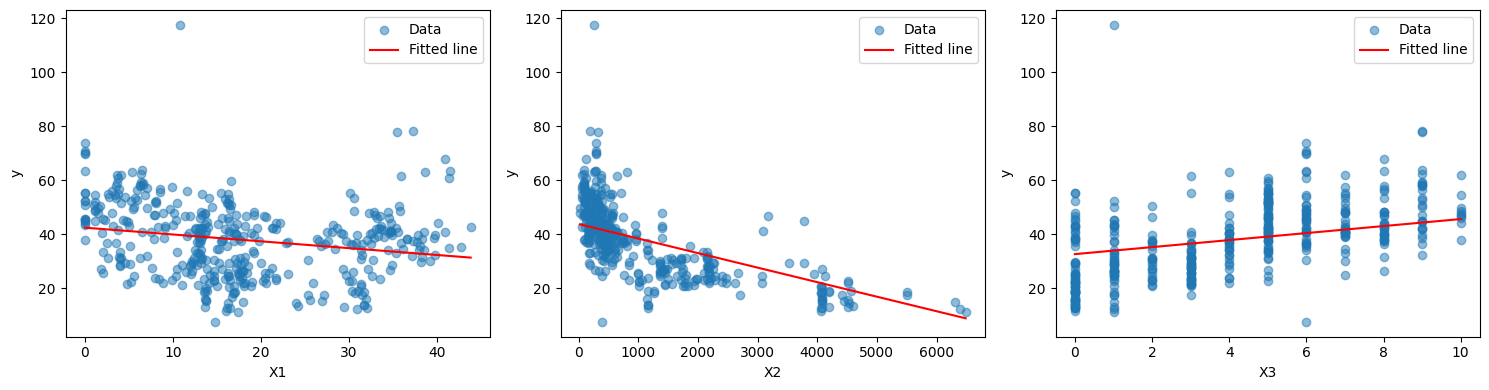

MSE (closed form): 84.76070642266241


In [48]:
x_line = X
y_line_fit = X_design @ theta_star

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].scatter(X[:, i], y, alpha=0.5, label="Data")
    X_mean = X.mean(axis=0)
    x_i_sorted = np.linspace(X[:, i].min(), X[:, i].max(), 100)
    X_plot = np.tile(X_mean, (100, 1))
    X_plot[:, i] = x_i_sorted
    y_pred = theta0_star + X_plot @ theta_star[1:]
    axes[i].plot(x_i_sorted, y_pred, color='red', label="Fitted line")
    axes[i].set_xlabel(f"X{i+1}")
    axes[i].set_ylabel("y")
    axes[i].legend()
plt.tight_layout()
plt.show()

print("MSE (closed form):", mean_squared_error(y, y_line_fit))